In [ ]:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt

    from sklearn.datasets import fetch_california_housing
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LinearRegression, Ridge
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
housing = fetch_california_housing(as_frame=True)
data = housing.frame

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Shape of Dataset:", data.shape)
print("\nColumn Names:")
print(data.columns)
print("\nMissing Values:")
print(data.isnull().sum())

Shape of Dataset: (20640, 9)

Column Names:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='str')

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [4]:
X = data.drop("MedHouseVal", axis=1)
y = data["MedHouseVal"]

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.20, random_state=42)

In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)
}

In [11]:
results = []

for model_name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results.append([model_name, rmse, r2])

comparison = pd.DataFrame(
    results,
    columns=["Model", "RMSE", "R2 Score"]
)

comparison

,Model,RMSE,R2 Score
0,Linear Regression,0.745581,0.575788
1,Ridge Regression,0.745554,0.575819
2,Decision Tree,0.724234,0.599732


In [12]:
best_model = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,RMSE,R2 Score
2,Decision Tree,0.724234,0.599732
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


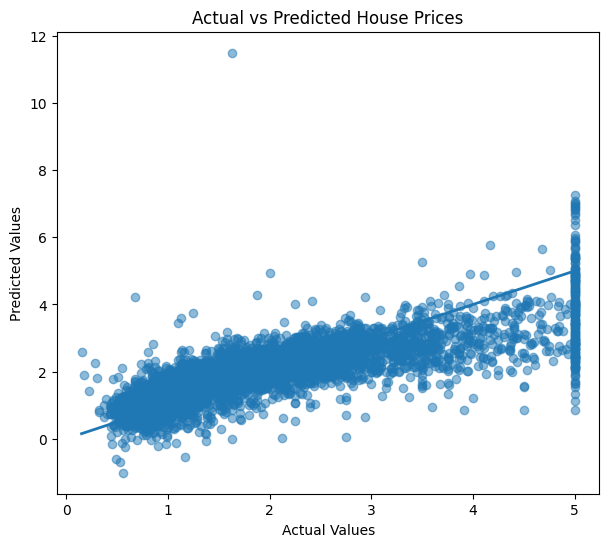

In [13]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.show()

In [14]:
print("Model Performance Comparison")
print(comparison)

best = comparison.loc[
    comparison["R2 Score"].idxmax(),
    "Model"
]

print("\nBest Performing Model:", best)

Model Performance Comparison
               Model      RMSE  R2 Score
0  Linear Regression  0.745581  0.575788
1   Ridge Regression  0.745554  0.575819
2      Decision Tree  0.724234  0.599732

Best Performing Model: Decision Tree
